In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch_geometric.datasets import QM9
from tqdm import tqdm

# ==========================================
# 1. DATA PROCESSING HELPER FUNCTIONS
# ==========================================
def extract_focal_neighborhoods(data, max_neighbors=7, d_max=5.0):
    num_atoms = data.pos.shape[0]
    dist_matrix = torch.cdist(data.pos, data.pos)
    molecule_neighborhoods = []
    
    for i in range(num_atoms):
        distances = dist_matrix[i]
        sorted_indices = torch.argsort(distances)
        sorted_distances = distances[sorted_indices]
        
        valid_mask = sorted_distances <= d_max
        valid_indices = sorted_indices[valid_mask]
        
        num_to_take = min(len(valid_indices), max_neighbors + 1)
        neighbor_indices = valid_indices[:num_to_take]
        
        subgraph_z = data.z[neighbor_indices].float()
        subgraph_pos = data.pos[neighbor_indices]
        
        if num_to_take < max_neighbors + 1:
            pad_size = (max_neighbors + 1) - num_to_take
            pad_z = torch.zeros(pad_size, dtype=torch.float32)
            pad_pos = torch.zeros((pad_size, 3), dtype=torch.float32)
            subgraph_z = torch.cat([subgraph_z, pad_z])
            subgraph_pos = torch.cat([subgraph_pos, pad_pos])
        
        molecule_neighborhoods.append({
            'atomic_numbers': subgraph_z, 
            'coordinates': subgraph_pos   
        })
    return molecule_neighborhoods

def encode_diagram_angles(neighborhoods, d_max=5.0):
    processed = []
    for nb in neighborhoods:
        Z_num = nb['atomic_numbers']
        pos = nb['coordinates']
        
        focal_pos = pos[0]
        rel_pos = pos - focal_pos
        x, y, z = rel_pos[:, 0], rel_pos[:, 1], rel_pos[:, 2]
        
        d = torch.sqrt(x**2 + y**2 + z**2)
        theta = torch.acos(torch.clamp(y / (d + 1e-7), -1.0, 1.0))
        phi = torch.atan2(x, z)
        
        is_ghost = (Z_num == 0)
        d = d.masked_fill(is_ghost, 0.0)
        theta = theta.masked_fill(is_ghost, 0.0)
        phi = phi.masked_fill(is_ghost, 0.0)
        
        # CORRECTED SCALING: Match the paper's 2*pi scaling
        Z_scaled = (Z_num / 10.0) * (2 * np.pi)
        d_scaled = (d / d_max) * (2 * np.pi)
        
        theta_scaled = theta  
        phi_scaled = (phi + np.pi) / 2.0  
        phi_scaled = phi_scaled.masked_fill(is_ghost, 0.0)
        
        features = torch.stack([Z_scaled, d_scaled, theta_scaled, phi_scaled], dim=1)
        processed.append(features.flatten()) 
        
    return torch.stack(processed)

# ==========================================
# 2. LOAD AND PROCESS QM9 DATASET
# ==========================================
print("Loading raw QM9...")
dataset = QM9(root='./data/QM9')
processed_dataset = []
target_property_idx = 4 # HOMO-LUMO Gap

# Processing 10 molecules for testing
num_molecules_to_process = 100

for i in tqdm(range(num_molecules_to_process), desc="Processing Molecules"):
    data = dataset[i]
    target_val = data.y[0, target_property_idx]
    
    neighborhoods = extract_focal_neighborhoods(data, d_max=5.0)
    quantum_features = encode_diagram_angles(neighborhoods, d_max=5.0)
    processed_dataset.append((quantum_features, target_val))

train_size = int(0.8 * len(processed_dataset))
training_data = processed_dataset[:train_size]
test_data = processed_dataset[train_size:]

print(f"\nTraining on: {len(training_data)} molecules | Testing on: {len(test_data)} molecules")

C:\Users\Sriram Nangunoori\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading raw QM9...


Processing Molecules: 100%|██████████| 100/100 [00:00<00:00, 670.33it/s]


Training on: 80 molecules | Testing on: 20 molecules


In [2]:
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# (Note: In standard Qiskit 1.0+, SPSA is often imported via algorithms. 
# If this import fails, `from qiskit_algorithms.gradients import SPSAEstimatorGradient` can be used)
from qiskit_algorithms.gradients import SPSAEstimatorGradient

# ==========================================
# 3. BUILD THE QUANTUM CIRCUIT
# ==========================================
print("\n--- Initializing Pure Quantum Circuit ---")
num_qubits, num_atoms, num_layers = 16, 8, 8

x_inputs = ParameterVector('x', 32)
theta_weights = ParameterVector('t', 384) 
pqc = QuantumCircuit(num_qubits)

# Feature Map (Corrected: No Entanglement here)
for i in range(num_atoms):
    qA, qB = 2*i, 2*i + 1
    pqc.rx(x_inputs[i*4 + 0], qA)
    pqc.ry(x_inputs[i*4 + 1], qA)
    pqc.rx(x_inputs[i*4 + 2], qB)
    pqc.ry(x_inputs[i*4 + 3], qB)

# Trainable Ansatz
weight_idx = 0
for layer in range(num_layers):
    for q in range(num_qubits):
        pqc.rz(theta_weights[weight_idx], q)
        pqc.ry(theta_weights[weight_idx+1], q)
        pqc.rz(theta_weights[weight_idx+2], q)
        weight_idx += 3
    for q in range(num_qubits):
        pqc.cx(q, (q + 1) % num_qubits)

observables = [SparsePauliOp("I" * (15 - i) + "Z" + "I" * i) for i in range(num_qubits)]

# ==========================================
# 4. BUILD THE FAST HYBRID PYTORCH LAYER
# ==========================================
estimator = StatevectorEstimator()
spsa_grad = SPSAEstimatorGradient(estimator, epsilon=0.01)

# Wrap circuit into a QNN
qnn = EstimatorQNN(
    circuit=pqc,
    observables=observables,
    input_params=x_inputs,
    weight_params=theta_weights,
    estimator=estimator,
    gradient=spsa_grad # The speed-up magic happens here!
)

# Initialize PyTorch Connector
initial_weights = np.random.uniform(-np.pi, np.pi, 384)
quantum_layer = TorchConnector(qnn, initial_weights=initial_weights)

# Define full hybrid model architecture
class Quantum3DGraphModel(nn.Module):
    def __init__(self, q_layer):
        super().__init__()
        self.quantum_layer = q_layer
        self.classical_mlp = nn.Sequential(
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        quantum_out = self.quantum_layer(x)
        mol_embedding = torch.sum(quantum_out, dim=0, keepdim=True)
        prediction = self.classical_mlp(mol_embedding)
        return prediction.squeeze()

hybrid_model = Quantum3DGraphModel(quantum_layer)
optimizer = optim.Adam(hybrid_model.parameters(), lr=0.01)
loss_fn = nn.L1Loss()

print("Fast SPSA Hybrid QNN Successfully Built!")


--- Initializing Pure Quantum Circuit ---
Fast SPSA Hybrid QNN Successfully Built!


In [3]:
import time

# ==========================================
# 5. FAST TRAINING LOOP
# ==========================================
print("\n=== Starting Optimized Hybrid Training ===")
epochs = 5 

for epoch in range(epochs):
    print(f"\n{'='*40}")
    print(f"--- STARTING EPOCH {epoch+1} ---")
    print(f"{'='*40}")
    
    epoch_loss = 0.0
    
    for mol_idx, (X_molecule, y_target) in enumerate(training_data):
        
        optimizer.zero_grad()
        
        # Forward Pass
        start_time = time.time()
        prediction = hybrid_model(X_molecule.float())
        
        # Calculate Loss
        y_tensor = y_target.clone().detach().float().squeeze()
        loss = loss_fn(prediction, y_tensor)
        
        # Backward Pass (SPSA calculates 384 gradients simultaneously)
        loss.backward()
        
        # Update Weights
        optimizer.step()
        
        epoch_loss += loss.item()
        
        end_time = time.time()
        print(f"Molecule {mol_idx+1}/{len(training_data)} | Target: {y_tensor.item():.4f} | Pred: {prediction.item():.4f} | Loss: {loss.item():.4f} | Time: {end_time - start_time:.2f}s")
        
    print(f"\n==> Epoch {epoch+1} Average Loss: {epoch_loss / len(training_data):.4f}")


=== Starting Optimized Hybrid Training ===

--- STARTING EPOCH 1 ---
Molecule 1/80 | Target: 13.7363 | Pred: 0.1675 | Loss: 13.5688 | Time: 46.04s
Molecule 2/80 | Target: 9.2491 | Pred: 0.2042 | Loss: 9.0449 | Time: 36.69s
Molecule 3/80 | Target: 9.8369 | Pred: 0.2037 | Loss: 9.6333 | Time: 26.90s
Molecule 4/80 | Target: 9.1185 | Pred: 0.2517 | Loss: 8.8668 | Time: 35.99s
Molecule 5/80 | Target: 10.3294 | Pred: 0.2700 | Loss: 10.0594 | Time: 27.01s
Molecule 6/80 | Target: 6.1579 | Pred: 0.2876 | Loss: 5.8703 | Time: 35.72s
Molecule 7/80 | Target: 12.0438 | Pred: 0.3329 | Loss: 11.7109 | Time: 71.62s
Molecule 8/80 | Target: 9.3526 | Pred: 0.3498 | Loss: 9.0027 | Time: 58.06s
Molecule 9/80 | Target: 8.7675 | Pred: 0.3454 | Loss: 8.4221 | Time: 67.06s
Molecule 10/80 | Target: 9.9049 | Pred: 0.3746 | Loss: 9.5303 | Time: 55.50s
Molecule 11/80 | Target: 6.3729 | Pred: 0.4035 | Loss: 5.9694 | Time: 62.99s
Molecule 12/80 | Target: 7.7416 | Pred: 0.4312 | Loss: 7.3105 | Time: 54.08s
Molecule 


=== Starting Evaluation on Unseen Test Set ===
Test Molecule 1/20 | Actual: 9.1158 | Predicted: 7.5086 | Error: 1.6072
Test Molecule 2/20 | Actual: 9.0777 | Predicted: 7.7104 | Error: 1.3674
Test Molecule 3/20 | Actual: 9.5947 | Predicted: 7.8679 | Error: 1.7268
Test Molecule 4/20 | Actual: 9.5376 | Predicted: 7.7256 | Error: 1.8120
Test Molecule 5/20 | Actual: 8.8981 | Predicted: 8.0688 | Error: 0.8293
Test Molecule 6/20 | Actual: 7.9103 | Predicted: 8.2931 | Error: 0.3828
Test Molecule 7/20 | Actual: 6.0464 | Predicted: 8.1545 | Error: 2.1082
Test Molecule 8/20 | Actual: 7.8369 | Predicted: 7.9670 | Error: 0.1301
Test Molecule 9/20 | Actual: 7.8314 | Predicted: 7.7669 | Error: 0.0646
Test Molecule 10/20 | Actual: 5.9294 | Predicted: 7.5690 | Error: 1.6396
Test Molecule 11/20 | Actual: 6.2450 | Predicted: 7.5409 | Error: 1.2958
Test Molecule 12/20 | Actual: 10.4029 | Predicted: 8.2951 | Error: 2.1079
Test Molecule 13/20 | Actual: 9.0478 | Predicted: 7.8707 | Error: 1.1771
Test Molecu

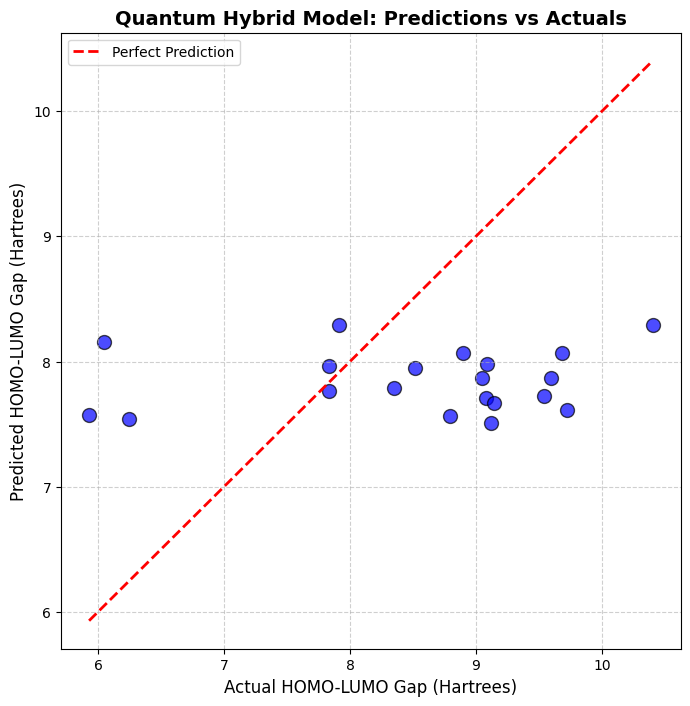

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# 6. TESTING / EVALUATION LOOP
# ==========================================
print("\n=== Starting Evaluation on Unseen Test Set ===")

hybrid_model.eval()

test_loss = 0.0
predictions_list = []
actuals_list = []

with torch.no_grad():
    for mol_idx, (X_molecule, y_target) in enumerate(test_data):
        
        # Forward Pass
        prediction = hybrid_model(X_molecule.float())
        
        # Format Targets
        y_tensor = y_target.clone().detach().float().squeeze()
        
        # Calculate Error
        loss = loss_fn(prediction, y_tensor)
        test_loss += loss.item()
        
        predictions_list.append(prediction.item())
        actuals_list.append(y_tensor.item())
        
        print(f"Test Molecule {mol_idx+1}/{len(test_data)} | Actual: {actuals_list[-1]:.4f} | Predicted: {predictions_list[-1]:.4f} | Error: {loss.item():.4f}")

average_test_loss = test_loss / len(test_data)
print(f"\n{'='*40}")
print(f"==> Final Test Mean Absolute Error (MAE): {average_test_loss:.4f} Hartrees")
print(f"{'='*40}")

# ==========================================
# 7. VISUALIZE RESULTS
# ==========================================
plt.figure(figsize=(8, 8))
plt.scatter(actuals_list, predictions_list, alpha=0.7, color='blue', edgecolors='k', s=100)

min_val = min(min(actuals_list), min(predictions_list))
max_val = max(max(actuals_list), max(predictions_list))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual HOMO-LUMO Gap (Hartrees)", fontsize=12)
plt.ylabel("Predicted HOMO-LUMO Gap (Hartrees)", fontsize=12)
plt.title("Quantum Hybrid Model: Predictions vs Actuals", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()